# Historical weather data for Vienna City Marathon dates

To access the weather on the days the marathon took place the following REST API was used: https://api.openweathermap.org

## Cleaning/Accessing the data

Import relevant libraries

In [2]:
!pip install python-dotenv

In [2]:
from pathlib import Path
from dotenv import load_dotenv
import os
import requests, time
import pandas as pd
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "CSV").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "CSV"
WEATHER_CSV_PATH = DATA_DIR / "weather.csv"
MARATHON_CSV_PATH = DATA_DIR / "vienna_city_marathon_all_years_participants.csv"


get key for the weather API from .env

In [ ]:
load_dotenv()
weather_key = os.getenv("weather_key")


save coordinates for Vienna so that it can be used in the API call

In [ ]:
LAT, LON = 48.2082, 16.3738

save relevant marathon dates (from 2000 onwards, 2020 was canceled)

In [ ]:
marathon_dates = {
    2017: "2017-04-23",
    2018: "2018-04-22", 2019: "2019-04-07",
    # 2020 cancelled
    2021: "2021-09-12", 2022: "2022-04-24", 2023: "2023-04-23",
    2024: "2024-04-21", 2025: "2025-04-06", 2026: "2026-04-19",
}

fetch historical weather on marathon dates

In [ ]:
def get_weather(date_str):
    dt = datetime.strptime(date_str, "%Y-%m-%d").replace(hour=9, tzinfo=timezone.utc)
    ts = int(dt.timestamp())

    r = requests.get(
        "https://api.openweathermap.org/data/3.0/onecall/timemachine",  # hardcoded
        params={
            "lat": LAT, "lon": LON,
            "dt": ts,
            "appid": weather_key,
            "units": "metric"
        }
    )
    if r.status_code != 200:
        print(f"  ✗ Error {r.status_code}: {r.json()}")
        return {}

    d = r.json().get("data", [{}])[0]
    return {
        "temp_c":     d.get("temp"),
        "feels_like": d.get("feels_like"),
        "humidity":   d.get("humidity"),
        "wind_kph":   round(d.get("wind_speed", 0) * 3.6, 1),
        "weather":    d.get("weather", [{}])[0].get("description"),
        "clouds":     d.get("clouds"),
        "rain_mm":    d.get("rain", {}).get("1h", 0),
    }

Fetch all relevant dates

In [ ]:
results = {}
for year, date in marathon_dates.items():
    print(f"Fetching {year}...", end=" ")
    results[year] = get_weather(date)
    print("✓")
    time.sleep(0.5)


build dataframe and save results in csv

In [ ]:
rows = [{"year": year, "date": date, **results.get(year, {})}
        for year, date in marathon_dates.items()]

df = pd.DataFrame(rows).set_index("year")
print(df)
df.to_csv(WEATHER_CSV_PATH)

## Visualisation

In [3]:
df = pd.read_csv(WEATHER_CSV_PATH)
df["date"] = pd.to_datetime(df["date"])
df["rained"] = df["rain_mm"] > 0
print(df.head())

   year       date  temp_c  feels_like  humidity  wind_kph           weather  \
0  2017 2017-04-23    9.13        5.82        50      25.2        few clouds   
1  2018 2018-04-22   21.66       21.19        50      14.4        few clouds   
2  2019 2019-04-07   13.00       12.13        68      27.4  scattered clouds   
3  2021 2021-09-12   23.30       23.38        65       4.8         clear sky   
4  2022 2022-04-24   15.24       14.60        68      32.2   overcast clouds   

   clouds  rain_mm  rained  
0      20        0   False  
1      24        0   False  
2      40        0   False  
3      10        0   False  
4     100        0   False  


The following plot shows the temperature in Vienna on Marathon day. Note that since the marathon used to be in may and now is in april (or was in september in 2021) the temperatures can't necessarily be compared.

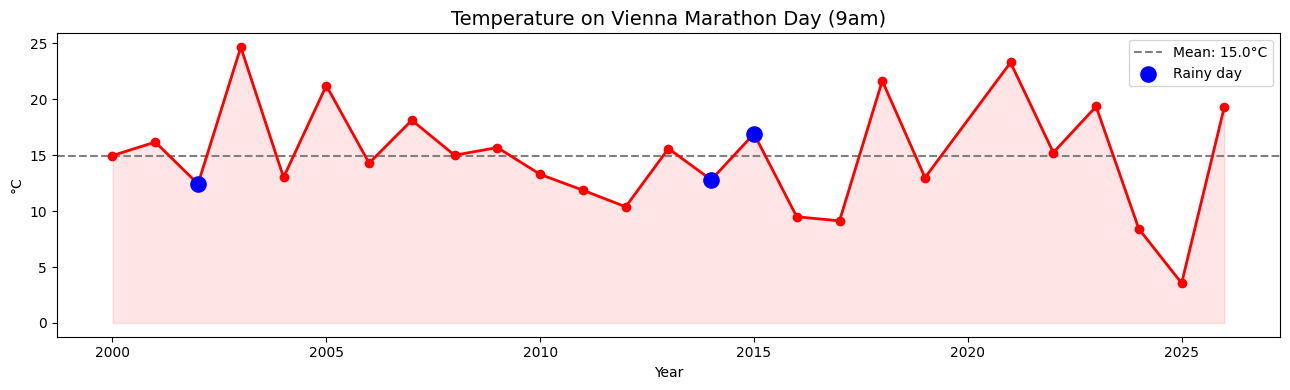

In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["year"], df["temp_c"], marker="o", color="red", linewidth=2, zorder=3)
ax.fill_between(df["year"], df["temp_c"], alpha=0.1, color="red")
ax.axhline(df["temp_c"].mean(), linestyle="--", color="gray",
           label=f"Mean: {df['temp_c'].mean():.1f}°C")
rainy = df[df["rained"]]
ax.scatter(rainy["year"], rainy["temp_c"], s=120, color="blue",
           zorder=5, label="Rainy day")
ax.set_title("Temperature on Vienna Marathon Day (9am)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("°C")
ax.legend()
plt.tight_layout()
plt.savefig("weather_temp.png", dpi=150)
plt.show()

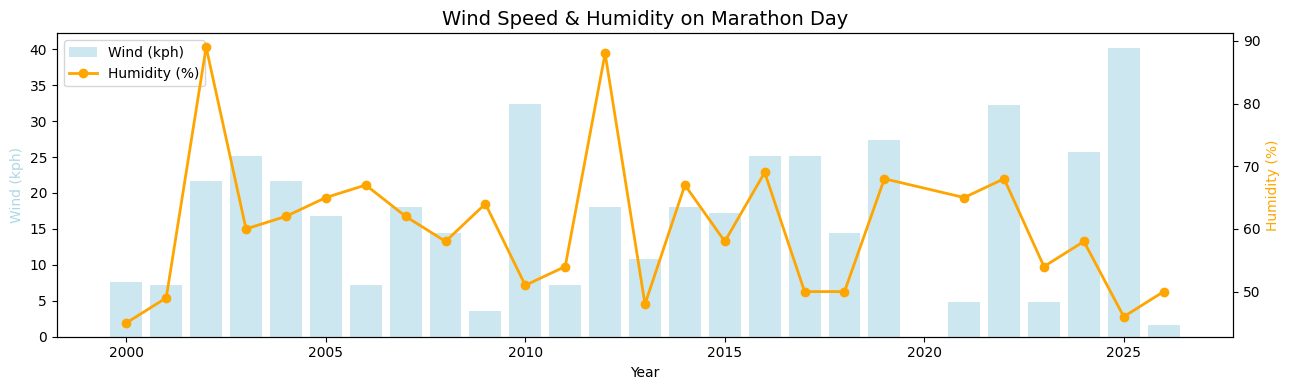

In [12]:
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.bar(df["year"], df["wind_kph"], color="lightblue", alpha=0.6, label="Wind (kph)")
ax2.plot(df["year"], df["humidity"], color="orange", marker="o", linewidth=2, label="Humidity (%)")
ax1.set_ylabel("Wind (kph)", color="lightblue")
ax2.set_ylabel("Humidity (%)", color="orange")
ax1.set_xlabel("Year")
ax1.set_title("Wind Speed & Humidity on Marathon Day", fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig("weather_wind_humidity.png", dpi=150)
plt.show()

The following plot shows the running comfort by year on the day of the Vienna Marathon. This comfort level was calculated using the Wet-Bulb Globe Temperature (WBGT), which measures heat stress as it affects the human body. Since solar radiation data was not available, a simplified formula was used that omits the globe temperature component.
Sources & Methodology:
* Wet-Bulb Temperature Approximation: Calculated using the Stull (2011) formula ("Wet-Bulb Temperature from Relative Humidity and Air Temperature", Journal of Applied Meteorology and Climatology).
* Risk Categories: The threshold values (< 18.0°C / 18.0–22.2°C / 22.3–25.6°C / 25.7–28.9°C / ≥ 29.0°C WBGT) are based on the official guidelines for endurance events established by the American College of Sports Medicine (ACSM) and the National Athletic Trainers' Association (NATA) (Casa et al., 2015).

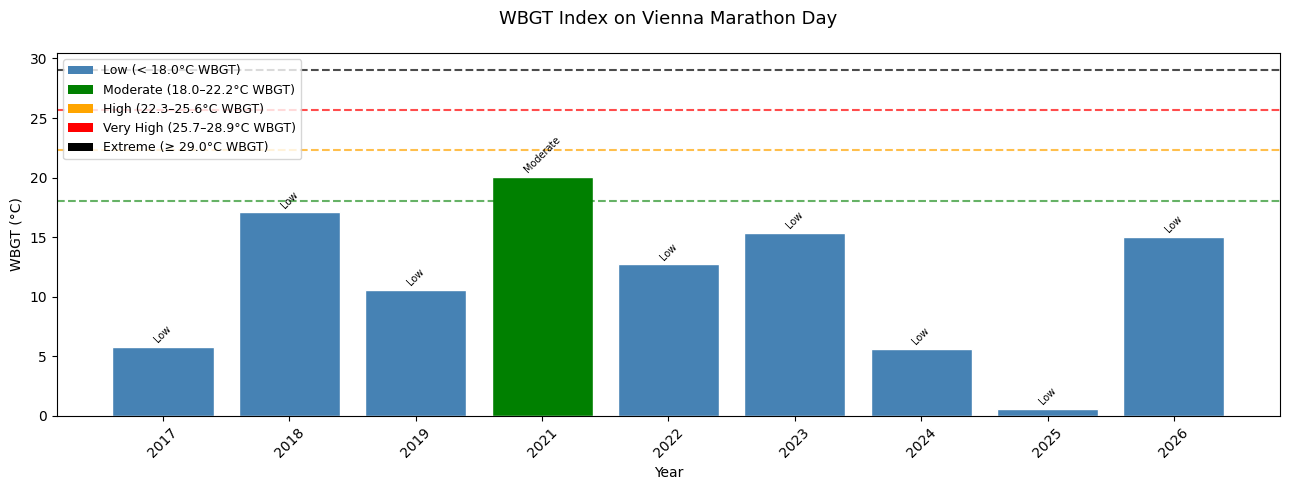

In [8]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch



def wet_bulb(T, rh):
    return (T * np.arctan(0.151977 * (rh + 8.313659) ** 0.5)
            + np.arctan(T + rh)
            - np.arctan(rh - 1.676331)
            + 0.00391838 * rh ** 1.5 * np.arctan(0.023101 * rh)
            - 4.686035)


df["wet_bulb"] = wet_bulb(df["temp_c"], df["humidity"])


df["wbgt"] = 0.7 * df["wet_bulb"] + 0.3 * df["temp_c"]


def wbgt_risk(w):
    if w < 18.0:
        return "Low"
    elif w < 22.3:
        return "Moderate"
    elif w < 25.7:
        return "High"
    elif w < 29.0:
        return "Very High"
    else:
        return "Extreme"


df["risk"] = df["wbgt"].apply(wbgt_risk)


color_map = {
    "Low": "steelblue",  # Normal conditions
    "Moderate": "green",  # Green Flag
    "High": "orange",  # Yellow Flag
    "Very High": "red",  # Red Flag
    "Extreme": "black"  # Black Flag (Event cancellation risk)
}
colors = df["risk"].map(color_map)


fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(df["year"].astype(str), df["wbgt"], color=colors, edgecolor="white")


ax.axhline(18.0, linestyle="--", color="green", alpha=0.6)
ax.axhline(22.3, linestyle="--", color="orange", alpha=0.7)
ax.axhline(25.7, linestyle="--", color="red", alpha=0.7)
ax.axhline(29.0, linestyle="--", color="black", alpha=0.7)


for bar, risk in zip(bars, df["risk"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            risk, ha="center", va="bottom", fontsize=7, rotation=45)


legend_elements = [
    Patch(facecolor="steelblue", label="Low (< 18.0°C WBGT)"),
    Patch(facecolor="green", label="Moderate (18.0–22.2°C WBGT)"),
    Patch(facecolor="orange", label="High (22.3–25.6°C WBGT)"),
    Patch(facecolor="red", label="Very High (25.7–28.9°C WBGT)"),
    Patch(facecolor="black", label="Extreme (≥ 29.0°C WBGT)"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper left")


ax.set_title("WBGT Index on Vienna Marathon Day\n", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("WBGT (°C)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("weather_wbgt.png", dpi=150)
plt.show()